# Employee Productivity Prediction


Rosie Navarro 

September 2026

## Purpose: 
The purpose of this project is to analyze employess and workplace data to identify factors that are associated with productivity and build a predictive model that can be used to support operational decision-making. 

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline


The first step of this project is to import the data that is being used. From there we can see the variables that are going to be used during the analysis. The data was obtained from the following Kaggle dataset: https://www.kaggle.com/datasets/adityaab1407/employee-productivity-and-satisfaction-hr-data

In [2]:
productivity = pd.read_csv('/Users/rosienavarro/Data_Science/hr_dashboard_data.csv')

productivity.head(10)

,Name,Age,Gender,Projects Completed,Productivity (%),Satisfaction Rate (%),Feedback Score,Department,Position,Joining Date,Salary
0,Douglas Lindsey,25,Male,11,57,25,4.7,Marketing,Analyst,Jan-20,63596
1,Anthony Roberson,59,Female,19,55,76,2.8,IT,Manager,Jan-99,112540
2,Thomas Miller,30,Male,8,87,10,2.4,IT,Analyst,Jan-17,66292
3,Joshua Lewis,26,Female,1,53,4,1.4,Marketing,Intern,Jan-22,38303
4,Stephanie Bailey,43,Male,14,3,9,4.5,IT,Team Lead,Jan-05,101133
5,Jonathan King,24,Male,5,63,33,4.2,Sales,Junior Developer,Jan-21,48740
6,Kyle Figueroa,33,Female,13,41,39,2.3,Sales,Analyst,Jan-18,73502
7,Shannon Allen,23,Female,4,92,68,2.8,HR,Intern,Jan-21,39670
8,Daryl Noble,30,Female,7,32,43,2.3,Marketing,Junior Developer,Jan-19,49323
9,Tracy Figueroa,39,Female,17,10,15,1.1,HR,Team Lead,Jan-04,92915


From this dataset, there is a total of 11 variables. 

The following is what each variable means: 
- Department: The department in which the employee works (e.g., Sales, HR, IT).
- Gender: Gender of the employee (Male, Female, Other).
- Age: Employee's age (between 22 and 60).
- Position: The role held by the employee (e.g., Manager, Analyst, Developer).
- Joining Date: The date the employee was hired.
- Name: Full Name of employee
- Projects Completed:Number of projects completed for the year (out of 25)
- Productivity: Productivity Score out of 100. 
- Satisfaction Score: score out of 100 from the employee. 
- Feedback Score: feedback score given to the employee (out of 5). 
- Salary: Employee pay (yearly). 


## Exploratory Data Analysis (EDA): 

An important step is to make sure that there is no missing values in the dataset. This will be done using the null(). If there is a missing value for any of the variables a number will show up next to it. 

In [3]:
productivity.isnull().sum()

Name                     0
Age                      0
Gender                   0
Projects Completed       0
Productivity (%)         0
Satisfaction Rate (%)    0
Feedback Score           0
Department               0
Position                 0
Joining Date             0
Salary                   0
dtype: int64

There are no missing value in the dataset. Info also allows us to see if there are any null values, which can be compared to the number of rows used. Additionally, info allows us to see the data type for each variable. 

There is a total of 5 string variables, 5 integers, 1 floats. 

In [4]:
productivity.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Name                   200 non-null    str    
 1   Age                    200 non-null    int64  
 2   Gender                 200 non-null    str    
 3   Projects Completed     200 non-null    int64  
 4   Productivity (%)       200 non-null    int64  
 5   Satisfaction Rate (%)  200 non-null    int64  
 6   Feedback Score         200 non-null    float64
 7   Department             200 non-null    str    
 8   Position               200 non-null    str    
 9   Joining Date           200 non-null    str    
 10  Salary                 200 non-null    int64  
dtypes: float64(1), int64(5), str(5)
memory usage: 17.3 KB


One thing to keep in mind, is the company has different departments, each one can have varying degrees of productivity and how productivity is measured. 

A pie chart can show us the percentage of employees in their corresponding department. 

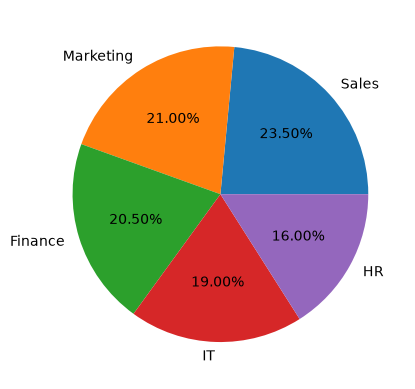

In [5]:
productivity.Department.value_counts().plot.pie(autopct='%.2f%%')

plt.show()

There are a total of 5 different departments (Finance, IT, HR, Sales, Marketing). For the most part out of all 200 employees, the number in each department is distributed somewhat evenly. Sales has the most employees (23.5%) and HR with the least (16%). 

Since each department can have different productivity scores, a bar plot can be used to see how productive each department is. 

In [6]:
department_product = (
    productivity.groupby("Department")["Productivity (%)"]
                .mean()
                .sort_values(ascending=False))

department_product

Department
IT           56.342105
HR           48.125000
Marketing    44.261905
Sales        44.212766
Finance      42.268293
Name: Productivity (%), dtype: float64

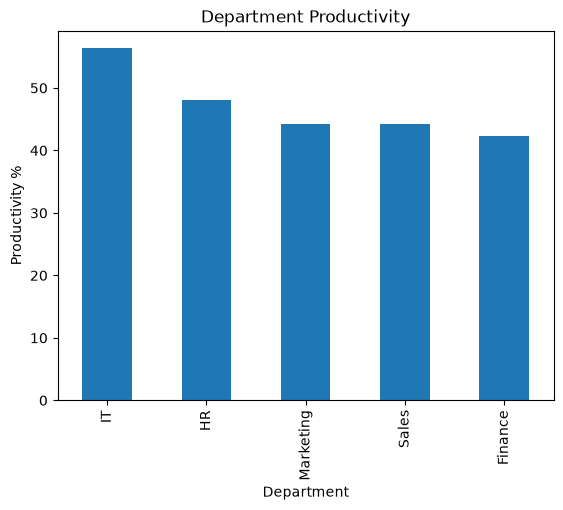

In [7]:
department_product.plot(kind="bar")

plt.title("Department Productivity")
plt.xlabel("Department")
plt.ylabel("Productivity %")
plt.show()

The department with the highest Productivity (%) was IT, with 56.3. Finance having the lowest productivity (42.3). 

This can also be done with Employee Satisfaction. 

In [8]:
department_sat = (
    productivity.groupby("Department")["Satisfaction Rate (%)"]
                .mean()
                .sort_values(ascending=False))

department_product

Department
IT           56.342105
HR           48.125000
Marketing    44.261905
Sales        44.212766
Finance      42.268293
Name: Productivity (%), dtype: float64

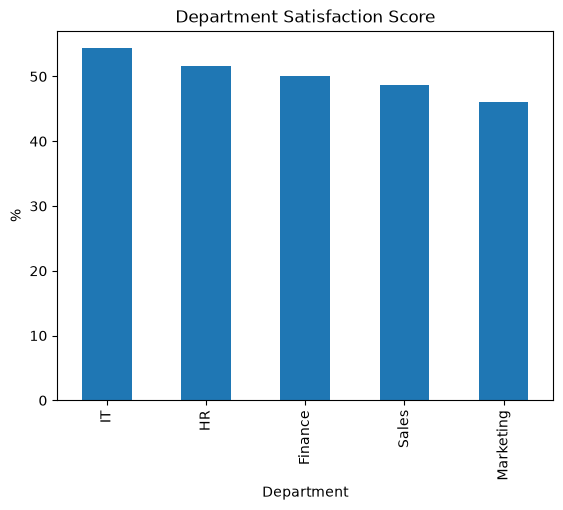

In [9]:
department_sat.plot(kind="bar")

plt.title("Department Satisfaction Score")
plt.xlabel("Department")
plt.ylabel("%")
plt.show()

The Employee Satisfication Score for each department is similar. Satisfaction does not depend on department. 

Correlation matrix can be made with all of the variables to see if there is correlation between the variables. If the value is closer to 0, this means that the relationship between the variables is weak. If the value is closer to -1 or 1 this means the relationship between the variables is stronger. 

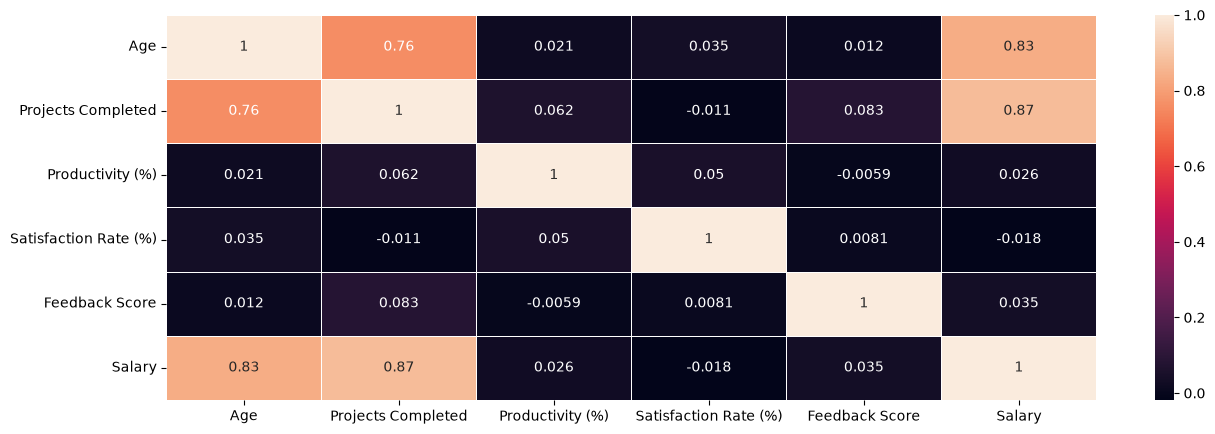

In [10]:
corrMatrix = productivity.select_dtypes(include="number").corr()

fig, ax = plt.subplots(figsize=(15,5))
sns.heatmap(corrMatrix, annot=True, linewidth=.5, ax=ax)

plt.show()

There are three relationships that stand out, Projects completed with Age, Projects Completed with Salary, and Age with Salary. All of their correlation coefficients are above 0.5 which indicate that there is a strong positive relationship between the variables. Although productivity did not have a strong positive/negative relationship between any of the variables, projects completed can be a measurement of work output. 

Projects completed and Salary have the highest correlation coefficient (0.87). Salary and Age also have a similar correlation coefficent of 0.83, this would make sense because it could indiciate that people who are older have more experience in the industry. Projects completed and Age also have a strong relationship (0.76) but it is lower than the two other relationships. Although they have a strong positive relationship this does not mean causation. 

A scatter plot shows the relationship between the variables. For this analysis, Salary vs Age, and Projects Completed vs Salary will be used. 

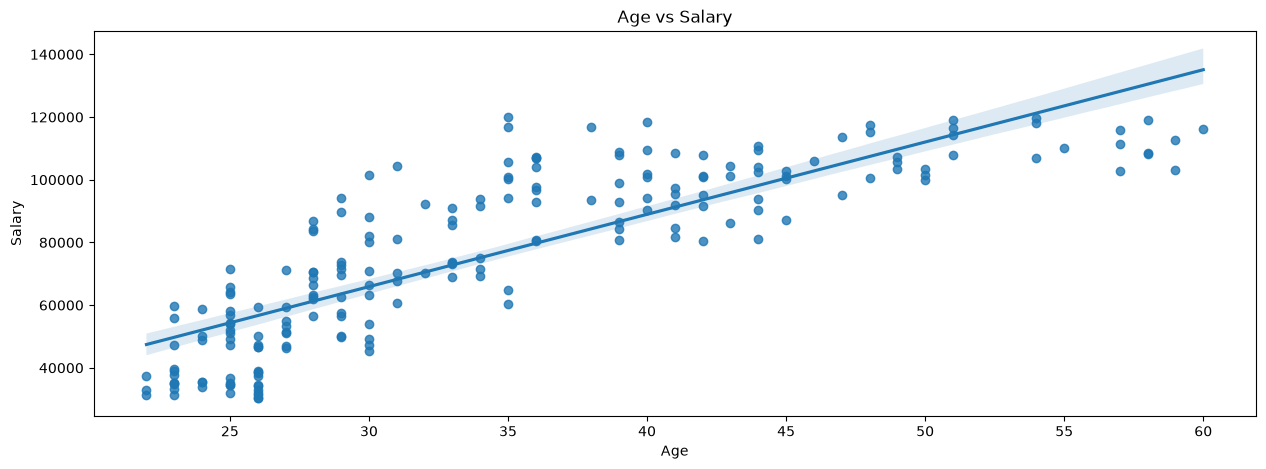

In [11]:
fig, ax = plt.subplots(figsize=(15,5))
sns.regplot(data=productivity, x="Age", y="Salary")

plt.title("Age vs Salary")
plt.ylabel("Salary")
plt.xlabel("Age")
plt.show()

As expected, there is a positive relationship between Age and Salary. There are more employees that are between the ages of 21 to 45. One interesting thing that can be seen in the scatter plot is that not everyone that is older is getting the highest salary. There are employees that are in 34 that are making the most.


Projects Completed and Salary will also have a positive relationship (from correlation coefficient)

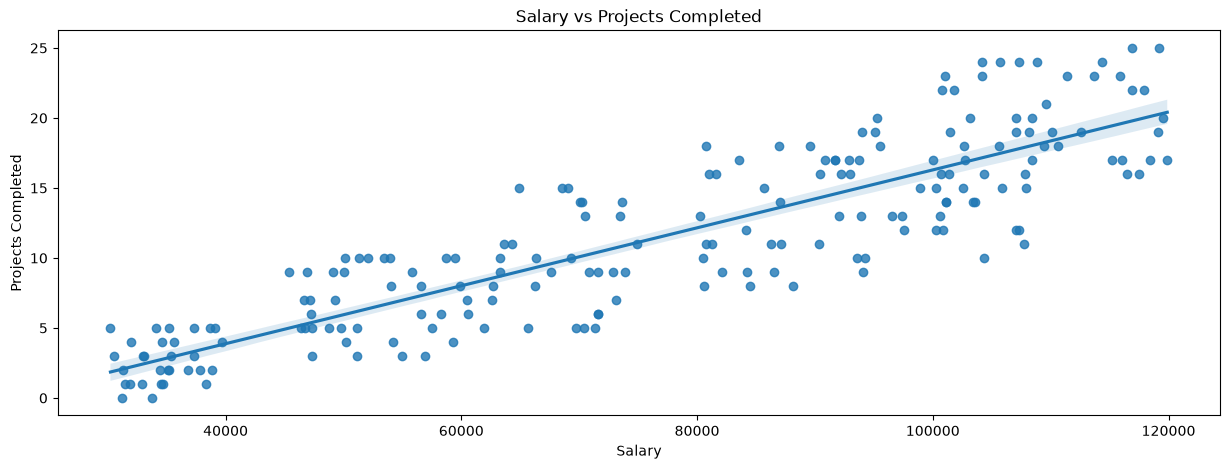

In [12]:
fig, ax = plt.subplots(figsize=(15,5))
sns.regplot(data=productivity, x="Salary", y="Projects Completed")

plt.title("Salary vs Projects Completed")
plt.xlabel("Salary")
plt.ylabel("Projects Completed")
plt.show()

One thing that can be seen immediately from this plot is a cluster around 40K, most of them complete around 5 porjects. For the most part, as more projects are completed salary also increases. This does not mean doing more projects CAUSES an increase in salary. There could be other factors to take into consideration. 

# Models:
## Model 1
The goal of the models is to determine whether employee characteristics (age, salary, department, etc.) can be used to predict the number of projects an employee completes. Projects completed is the measurement that is being used for productivity. 

For the first model, 

In [13]:
X = productivity[["Salary"]]
y = productivity["Projects Completed"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model1 = LinearRegression()
model1.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Salary']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-4.448
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [15]:
y_pred = model1.predict(X_test)



### Evaluation for model 1: 
To evaluate the model, R^2, RMSE, and MAE will be used to see how accurate the model's predictions were.

R^2 shows how well the model is able to explain the variation. The closer it is to 1 (or 100%), the better the model is at explaining the variation. 

RMSE (root mean square error) measures the sqaure root of the average magnitude of error, between the predicted and actual values. If the value is lower it means that there were more accurate predictions. 

MAE (mean absolute error) measures the difference between the predicted and true values. Lower number also indicates the model's guesses are closer to the real values. 

In [16]:
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(r2)
print(rmse)
print(mae)

0.7494849897387972
3.295805037456821
2.879421500290589


R^2 has a value of 0.75. Salary explains 75% of the variation in Projects completed. 
RMSE has a value of 3.3 which means that the predictions were off by around 3.3 projects. 
MAE has a value of 2.88 which means on average the prediction was off by 2.88 projects. 

Since model 1 was only able to predict 75% of the variation, an additional model can be made to see if another variable is able to better explain the variation. 

## Model 2: 
Model 2 will continue to use Projects completed, but instead of salary, Age will be used. 


In [17]:
X_age = productivity[["Age"]]
y_age = productivity["Projects Completed"]

X_age_train, X_age_test, y_age_train, y_age_test = train_test_split(
    X_age, y_age, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X_age_train, y_age_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.48]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Age']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-5.266
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [18]:
y_age_pred = model2.predict(X_age_test)

#### Evaluation for Model 2:

In [19]:
r2_age = r2_score(y_age_test, y_age_pred)
rmse_age = np.sqrt(mean_squared_error(y_age_test, y_age_pred))
mae_age = mean_absolute_error(y_age_test, y_age_pred)

print(r2_age)
print(rmse_age)
print(mae_age)

0.5804440045955899
4.265201983580053
3.5446488129461997


For this model R^2 was lower, it has a value of 0.58. This means the model was only able to explain 58% of the variation, which is lower the model 1. 

Additionally RMSE (4.26) and MAE (3.5) are greater values compared to model 1. This indicates the model 2 predicts less accurate predictions compared to model 1. 

## Model 3: 
For the last model, multiple variables will be used to see if it increases the model's accuracy. 

For this model, Salary and Age will be used. 

In [20]:
X_mult = productivity[["Salary", "Age"]]
y_mult = productivity["Projects Completed"]

X_mult_train, X_mult_test, y_mult_train, y_mult_test = train_test_split(
    X_mult, y_mult, test_size=0.2, random_state=42)

model3 = LinearRegression()
model3.fit(X_mult_train, y_mult_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[0. ,0.05]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['Salary','Age']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-4.977
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [21]:
y_mult_pred = model3.predict(X_mult_test)

In [22]:
r2_mult = r2_score(y_mult_test, y_mult_pred)
rmse_mult = np.sqrt(mean_squared_error(y_mult_test, y_mult_pred))
mae_mult = mean_absolute_error(y_mult_test, y_mult_pred)

print(r2_mult)
print(rmse_mult)
print(mae_mult)

0.7552045569151329
3.25796415145407
2.8479297882498833


Having both of the variables (age and salary) did improve the model, but slightly. R^2 only increased by 0.01 comparing to model 1. RMSE was 3.26 and MAE ws 2.85. Although model 3 performed slightly better than model 1, the results are not much different. 

## Model 4: 
The final model will look at to categorical variables (position and department). These variables were not in the correlation matrix because they were categorical. In order to see if they can act like predictors, Department and Position need to be changed to numeric values, which can be done using a Hot Encoder. 
Evaluation will be the same. 

In [59]:
X = productivity[["Salary", "Department", "Position"]]
y = productivity["Projects Completed"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"),
         ["Department", "Position"])
    ],
    remainder="passthrough"
)

model4 = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model4.fit(X_train, y_train)

y_pred = model4.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(r2)
print(rmse)
print(mae)

0.7384244265296989
3.3677762493479673
2.8229158380400414



This shows that salary is doing more of the predicitive work. Additional variable/factors does not provide additional predictive information. In this case for model 4, the model was less accurate compared model 1. 

Model 4 has an R^2 of 0.73 which means that the model was able to explain 73% of the variation. It had a RMSE value of 3.4 and MAE value of 2.8. The results were similar, but adding more variables does not mean that the model will be better. 


# Conclusion: 
The regression analysis showed that employee characteristics can be used to predict the number of projects that are completed. Salary had the strongest model R^2 of 0.75, an RMSE of 3.30, and an MAE of 2.88. The second regression model performed worse, with an R^2 of 0.58, an RMSE of 4.26, and an MAE of 3.50. A multiple linear regression model using Salary and Age performed slightly better than the Salary-only model, with an R^2 of 0.76, an RMSE of 3.26, and an MAE of 2.85.

This shows that adding AGe, Department, and Postion did not provide additional predictive value. Salary was the strongest predictor, adding other variables did not improve the model.

## Business Recommendations: 
The following are some recommendations the company can look into to see what other predictors are associated with an increase in the number of projects completed:

1. Although salary was the strongest predictor, this does not mean increasing salary will directly increase productivity. There should be an investigation on other factors, like experience, responsibility, and tenure to see if this explains the relationship between salary and productivity.
2. There was still variation that was not explained (25%), additional factors/variables can be collected to provide a better understanding of factors that can be associated with productivity. Some factors to consider are, workload, hours worked weekly, responsibilities, etc.
3. With the addition of the second recommendation, workload, hours worked, and team size can be used to identify productivity patterns and areas that require additional support. Manager can them implement these changes if necessary.
4. The company can still monitor the number of projects that are completed. There were differences in the number of projects completed by department. They can use this information to see the areas that require more training, more employees, or support in general. 

